In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load dataset
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Step 2: understand the data

In [3]:
# Check datatype
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Step 3: EDA

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

Segregating the categorical and numerical data

In [7]:
val_num = df.select_dtypes(include=np.number)
val_cat = df.select_dtypes(exclude=np.number)

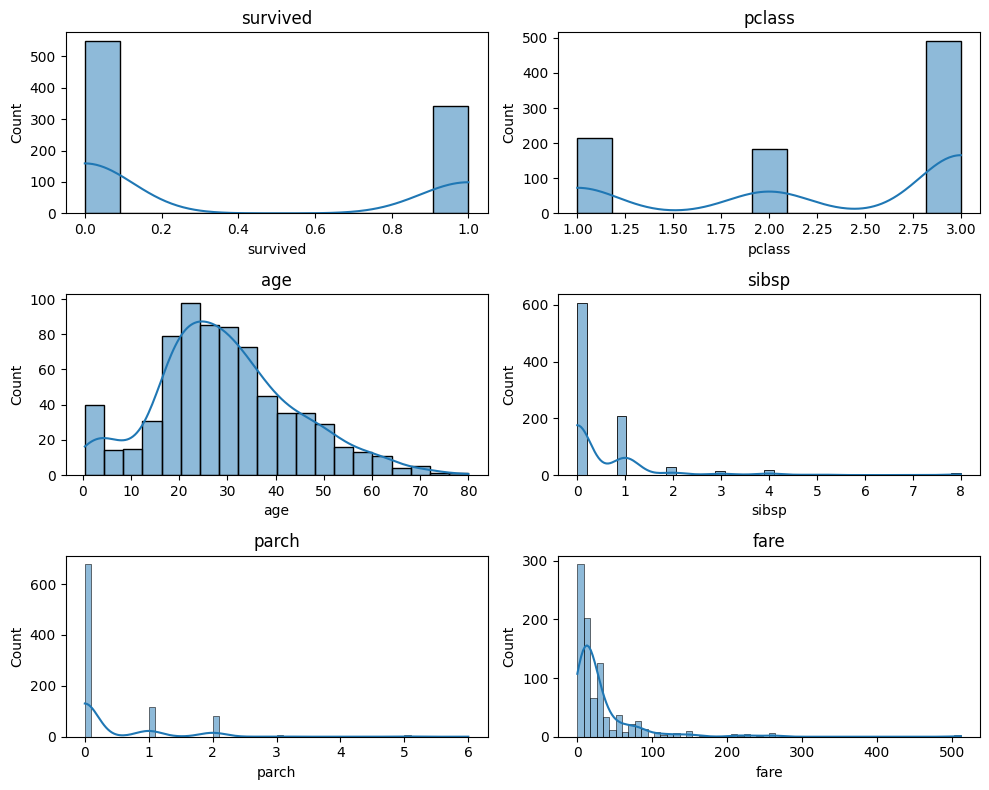

In [8]:
# For val_num
plt.figure(figsize= (10,8))
a = 3
b = 2
c = 1
for i in val_num:
    plt.subplot(a,b,c)
    sns.histplot(df[i], kde= True)
    plt.title(i)
    c += 1
plt.tight_layout()
plt.show()

# Visualize the categorical data

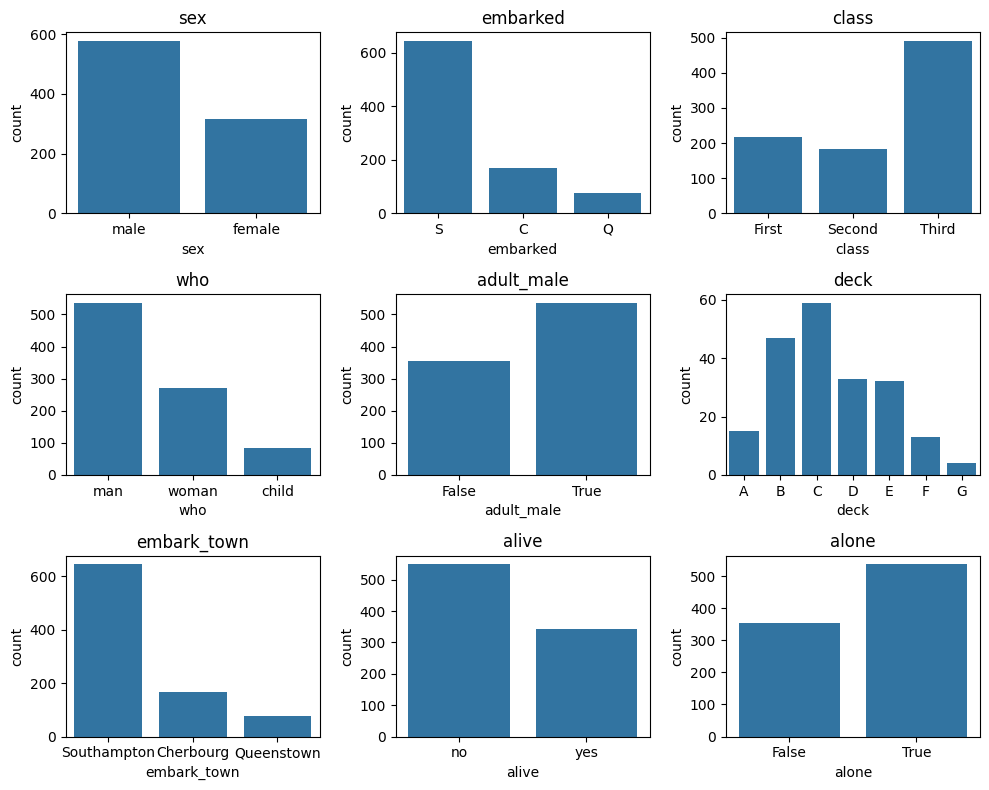

In [9]:
plt.figure(figsize= (10,8))
a = 3
b = 3 # Changed from 2 to 3 to accommodate more subplots
c = 1
for i in val_cat:
  plt.subplot(a,b,c)
  sns.countplot(x = df[i], data = df)
  plt.title(i)
  c += 1

plt.tight_layout()
plt.show()

In [10]:
# drop irrelevent column
df.drop(["class","who","deck", "alive"], axis =1, inplace = True)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,True,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,False,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,False,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,False,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,True,Southampton,True


Handling missing values

In [11]:
# checking missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
adult_male       0
embark_town      2
alone            0
dtype: int64

Outlier Detection

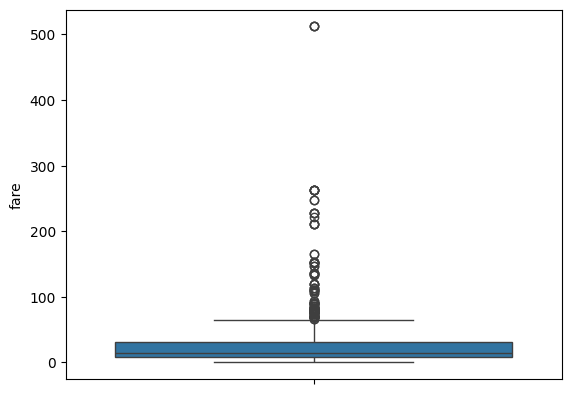

In [12]:
sns.boxplot(df["fare"])
plt.show()

<Axes: xlabel='fare', ylabel='Count'>

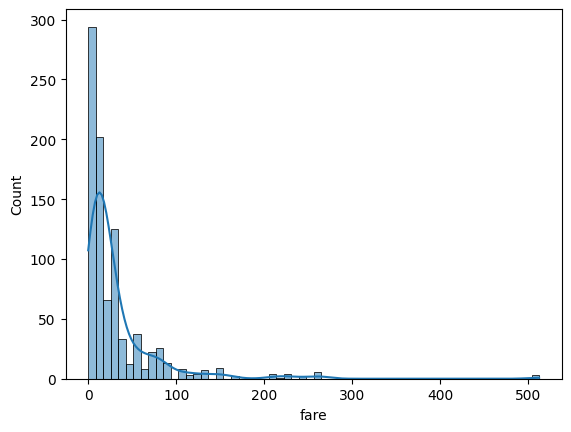

In [13]:
sns.histplot(df['fare'], kde=True)

In [14]:
# by IQR Method
# for skewed data
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['fare'] < lower) | (df['fare'] > upper)]
# print(outliers.value_counts)

In [15]:
# by IQR Method
# for skewed data
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['age'] < lower) | (df['age'] > upper)]
# print(outliers.value_counts)
print(len(outliers))

11


In [16]:
# # Z score
# # for normally distributed data
# from scipy.stats import zscore

# z = zscore(df['fare'])

# outliers = df[abs(z) > 3]

Treating Outliers
 * for Right Skewed: log Transformation
 * Robust Scaling (Use median and IQR)


In [17]:
# df["fare"] = np.log1p(df["fare"])

In [18]:
# Feature Engineering
# handling missing values
# age
df["age"] = df["age"].fillna(df["age"].mean())

In [19]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embarked"].unique()

<ArrowStringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

In [20]:
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])
df["embark_town"].unique()

<ArrowStringArray>
['Southampton', 'Cherbourg', 'Queenstown']
Length: 3, dtype: str

In [21]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
adult_male     0
embark_town    0
alone          0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(111)

Investigate Duplicates

In [23]:
df[df.duplicated()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,embark_town,alone
47,1,3,female,29.699118,0,0,7.7500,Q,False,Queenstown,True
76,0,3,male,29.699118,0,0,7.8958,S,True,Southampton,True
77,0,3,male,29.699118,0,0,8.0500,S,True,Southampton,True
87,0,3,male,29.699118,0,0,8.0500,S,True,Southampton,True
95,0,3,male,29.699118,0,0,8.0500,S,True,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...
870,0,3,male,26.000000,0,0,7.8958,S,True,Southampton,True
877,0,3,male,19.000000,0,0,7.8958,S,True,Southampton,True
878,0,3,male,29.699118,0,0,7.8958,S,True,Southampton,True
884,0,3,male,25.000000,0,0,7.0500,S,True,Southampton,True


In [24]:
# drop useless colum
df.drop(['adult_male', 'embark_town'], inplace=True, axis=1)

In [25]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


Step 6: Feature Engineering


In [26]:
df["family_size"] = df["sibsp"] + df["parch"] + 1

In [27]:
df.drop(["sibsp", "parch"], axis=1, inplace=True)

Step 7: Encoding

In [28]:
df.head()

,survived,pclass,sex,age,fare,embarked,alone,family_size
0,0,3,male,22.0,7.2500,S,False,2
1,1,1,female,38.0,71.2833,C,False,2
2,1,3,female,26.0,7.9250,S,True,1
3,1,1,female,35.0,53.1000,S,False,2
4,0,3,male,35.0,8.0500,S,True,1


In [29]:
column = ["sex", "alone"]
from sklearn.preprocessing import LabelBinarizer
lb = LabelBinarizer()
for i in column:
    df[i] = lb.fit_transform(df[i])

In [30]:
df.head()

,survived,pclass,sex,age,fare,embarked,alone,family_size
0,0,3,1,22.0,7.2500,S,0,2
1,1,1,0,38.0,71.2833,C,0,2
2,1,3,0,26.0,7.9250,S,1,1
3,1,1,0,35.0,53.1000,S,0,2
4,0,3,1,35.0,8.0500,S,1,1


In [31]:
df = pd.get_dummies(df, columns=["embarked"], dtype=int)

In [32]:
df.head()

,survived,pclass,sex,age,fare,alone,family_size,embarked_C,embarked_Q,embarked_S
0,0,3,1,22.0,7.2500,0,2,0,0,1
1,1,1,0,38.0,71.2833,0,2,1,0,0
2,1,3,0,26.0,7.9250,1,1,0,0,1
3,1,1,0,35.0,53.1000,0,2,0,0,1
4,0,3,1,35.0,8.0500,1,1,0,0,1


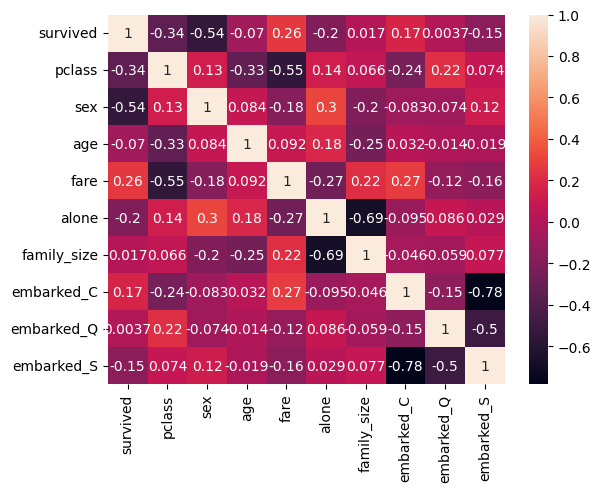

In [33]:
sns.heatmap(df.corr(), annot=True)
plt.show()

Step : Target value


In [34]:
X = df.drop("survived", axis=1)
y = df["survived"]

Step 9:Feature Scaling


In [35]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x = sc.fit_transform(X)

In [36]:
df.head()

,survived,pclass,sex,age,fare,alone,family_size,embarked_C,embarked_Q,embarked_S
0,0,3,1,22.0,7.2500,0,2,0,0,1
1,1,1,0,38.0,71.2833,0,2,1,0,0
2,1,3,0,26.0,7.9250,1,1,0,0,1
3,1,1,0,35.0,53.1000,0,2,0,0,1
4,0,3,1,35.0,8.0500,1,1,0,0,1


In [37]:
# Train Test and Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

Step 11: Train Model

In [38]:
# imporive FN = 20
df["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

Step 13: Evaluation

In [39]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight= "balanced")
lr.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
y_pred = lr.predict(x_test)
print("Prediction", y_pred[:10])
print("Actual", y_test[:10].values)

Prediction [0 0 0 1 1 1 1 0 1 1]
Actual [1 0 0 1 1 1 1 0 1 1]


In [41]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8156424581005587
[[85 20]
 [13 61]]
              precision    recall  f1-score   support

           0       0.87      0.81      0.84       105
           1       0.75      0.82      0.79        74

    accuracy                           0.82       179
   macro avg       0.81      0.82      0.81       179
weighted avg       0.82      0.82      0.82       179



Improve overall Accuracy
* Random Forest
* XGBoost
* Gradient Boosting

As the accuracy still very low then we'll try another method by creating some new features

HyperTunning Parameter

In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

model = {
    "Random_forest": (RandomForestClassifier(),
    {
        "n_estimators": [100,200],
        "max_depth" : [5,10,15],
    }
    ),

    "Gradient_Boosting": (GradientBoostingClassifier(
      random_state=42),
        {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 5, 7],
        }
    ),

    "XGBoost": (XGBClassifier(random_state=42),
    {
        "n_estimators": [100, 200],
        "max_depth": [5, 10, 15],
        "learning_rate": [0.01, 0.1],
    }
    )
}
for i, (model, params) in model.items():

    grid = GridSearchCV(model, params, cv=5, scoring = "accuracy", n_jobs= -1)
    grid.fit(x_train, y_train)

    print(f"\n{i}")
    print("Best Score", grid.best_score_)
    print("Best Params", grid.best_params_)


Random_forest
Best Score 0.8313995863291638
Best Params {'max_depth': 5, 'n_estimators': 100}

Gradient_Boosting
Best Score 0.8286319314488327
Best Params {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}

XGBoost
Best Score 0.8286023835319609
Best Params {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}


In [53]:
rf = RandomForestClassifier(n_estimators= 100, max_depth= 15)
rf.fit(x_train, y_train)
rf.score(x_test, y_test)
y_pred = rf.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8379888268156425
[[91 14]
 [15 59]]
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       105
           1       0.81      0.80      0.80        74

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



### Dumping Model and Preprocessing Objects for Streamlit UI

To make predictions on new data in your Streamlit application, it's crucial to use the same preprocessing steps that were applied to the training data. This includes:

1.  **The trained `RandomForestClassifier` model (`rf`)**
2.  **The fitted `StandardScaler` object (`sc`)**
3.  **The fitted `LabelBinarizer` object (`lb`)**

We will save these three objects into a single pickle file.

In [55]:
import pickle

# Create a dictionary to hold all necessary objects
model_components = {
    'model': rf, # Your trained RandomForestClassifier model
    'scaler': sc, # Your fitted StandardScaler
    'binarizer': lb # Your fitted LabelBinarizer
}

# Define the path to save the pickle file. Consider saving it in a Colab-accessible location.
pickle_file_path = 'titanic_model_and_preprocessors.pkl'

# Dump the dictionary into a pickle file
with open(r"C:\Users\dell\Downloads\Titanic Analysis\titanic_model_and_preprocessors.pkl", "wb") as f:
    pickle.dump(model_components, f)

print(f"All model components saved successfully to '{pickle_file_path}'")

All model components saved successfully to 'titanic_model_and_preprocessors.pkl'
